<!-- Codex test: first cell touched -->
This notebook records the creation of the `SHENDURE_BOUNDS` preset object and some plots illustrating modeling choices.

Setup.

In [ ]:
import scMPRAforge as scm
#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

2025-11-19 14:37:00.388967: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-19 14:37:00.392195: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/software/2024a/software/code-server/4.103.0/lib:/apps/software/2024a/software/gettext/0.22.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libiconv/1.17-GCCcore-13.3.0/lib:/apps/software/2024a/software/ncurses/6.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/apps/software/2024a/software/XZ/5.4.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/expat/2.6.2-GCCcore-13.3.0/lib:/apps/software/2024a/software/cUR

In [1]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client=Client(cluster)

2025-11-19 14:39:38,792 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:39589' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'lambda-a2630a26f5a7f1c7fc16bc9dbf1a9090', 'lambda-97d17f30c141a754d9b5171562c22859', 'lambda-00da96fd3480c6b489949299b4f252ce', 'lambda-2828506c5fe528ae24f5b09038902304', 'lambda-cffe3a139d205731173f48f67785d811', 'lambda-44520dfa43dace9c3da3f4398fe59891', 'lambda-f32f070eee9f4c63de94f38f1cffe098', 'lambda-12cb56c6f98205b6f151d1e469beaeb9', 'lambda-a3ba5c4ae2c5e075ec4a2dc8dd3e334b', 'lambda-d6b0b7b9e5be3a2e27d5c4edfb9d2845', 'lambda-20a59faff9aed6ae48ab8093b4c50d15', 'lambda-aa2369d217b98e794f9634286d777821', 'lambda-0fa1a0a10ad4993093e59921d543a24d', 'lambda-9ebc5a99ed53863c7da8adc8b3d1b85b', 'lambda-614a02aad77b20c218985eacf4a7024d', 'lambda-44720c8973e339df846a6ed15d15df4d', 'lambda-3c5905b4cd33a978966a8808416b9b5f', 'lambda-98c2bd3a08ea6a8248ebc3a5f78d3f24', 'lambda-54c2f9c8caf3a7c2f4f36816e0af

Load shendure ortho object.

In [2]:
path="/home/mcn26/project_pi_skr2/shared/tabula_data/shendure"
name="ortho_primordial_v3"
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
primordial=scm.ortho.load(client,path,name)

Create the bounds

In [3]:
shendure_bounds=scm.Bounds.from_ortho(primordial)

scMPRAforge: INFO: Computed a total of 414.7088384600356 estimated collision events, out of a total of 781874.70883846, or 0.05304031883524153%


Let's make some plots showing why we chose nb:

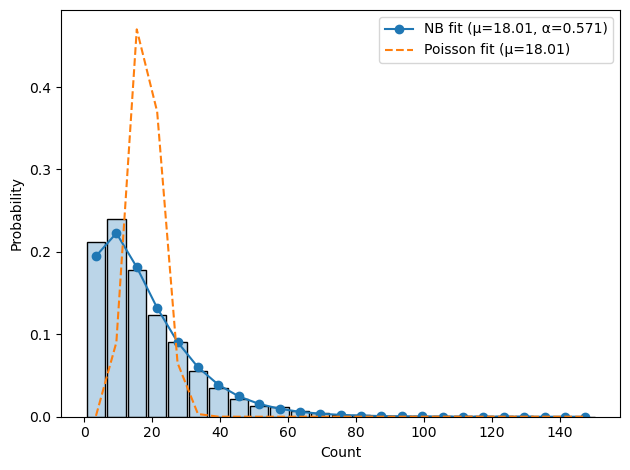

In [4]:
shendure_bounds.transfection_model.plot()

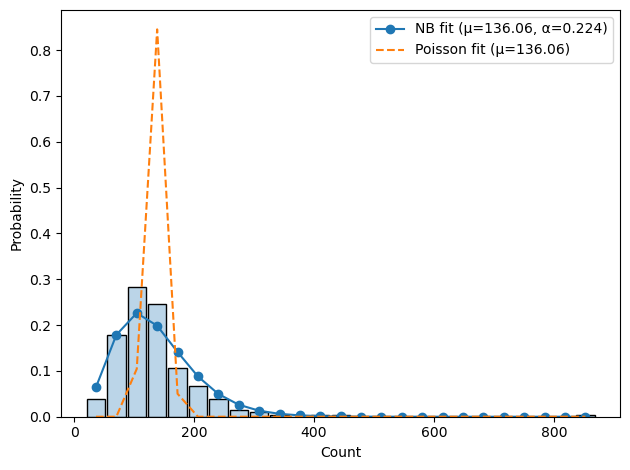

In [5]:
shendure_bounds.library_model.plot()

Now let's save the object:

In [6]:
shendure_bounds.to_tgz("scMPRAforge/presets/shendure_bounds.tgz")

In [8]:
cluster.close()
client.close()